<a href="https://colab.research.google.com/github/BabimBeam/BSC_DPDM2025/blob/main/final_BSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ไม่ถูก เดี๋ยวว่างๆจะแก้

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# 1. สร้างข้อมูลตัวอย่าง (สมมติข้อมูล 20 แถวตามโจทย์)
data = pd.read_csv('/content/Book1.csv')
df = data
df

,split,Day,Season,Humidity,cloud cover,rainfall
0,train,1,rainy,high,heavy,rain
1,train,2,rainy,high,heavy,rain
2,train,3,rainy,high,moderate,rain
3,train,4,hot,low,clear,no rain
4,train,5,hot,low,clear,no rain
5,train,6,rainy,high,heavy,rain
6,train,7,rainy,NaN,heavy,rain
7,train,8,cool,medium,moderate,rain
8,train,9,hot,low,NaN,no rain
9,train,10,cool,medium,moderate,rain


In [ ]:
# 2. การเตรียมข้อมูล (Data Preparation)
# 2.1 เติมข้อมูลที่ขาดหายไปด้วยค่าที่พบบ่อยที่สุด (mode)
for column in df.columns:
    df[column].fillna(df[column].mode()[0], inplace=True)
data

/tmp/ipykernel_803/633253950.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
/tmp/ipykernel_803/633253950.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,split,Day,Season,Humidity,cloud cover,rainfall
0,train,1,rainy,high,heavy,rain
1,train,2,rainy,high,heavy,rain
2,train,3,rainy,high,moderate,rain
3,train,4,hot,low,clear,no rain
4,train,5,hot,low,clear,no rain
5,train,6,rainy,high,heavy,rain
6,train,7,rainy,high,heavy,rain
7,train,8,cool,medium,moderate,rain
8,train,9,hot,low,heavy,no rain
9,train,10,cool,medium,moderate,rain


In [ ]:
# 2.2 แปลงข้อมูลเป็นตัวเลข (Data Encoding)
df['Season'] = df['Season'].map({'hot': 0, 'cool': 1, 'rainy': 2})
df['Humidity'] = df['Humidity'].map({'low': 0, 'medium': 1, 'high': 2})
df['cloud cover'] = df['cloud cover'].map({'clear': 0, 'moderate': 1, 'heavy': 2})
df['rainfall'] = df['rainfall'].map({'no rain': 0, 'rain': 1})

In [ ]:
df

,split,Day,Season,Humidity,cloud cover,rainfall
0,train,1,2,2,2,1
1,train,2,2,2,2,1
2,train,3,2,2,1,1
3,train,4,0,0,0,0
4,train,5,0,0,0,0
5,train,6,2,2,2,1
6,train,7,2,2,2,1
7,train,8,1,1,1,1
8,train,9,0,0,2,0
9,train,10,1,1,1,1


In [ ]:
# แยกฟีเจอร์ (X) และเป้าหมาย (y)
X = df.drop('rainfall', axis=1)
y = df['rainfall']

In [ ]:
### 3. การแบ่งข้อมูล (Data Splitting)

ข้อมูลถูกแบ่งออกเป็น 2 ส่วนหลักๆ คือ:

*   **X (Features):** คือคอลัมน์ทั้งหมดที่ใช้ในการทำนาย (ได้แก่ 'split', 'Day', 'Season', 'Humidity', 'cloud cover')
*   **y (Target):** คือคอลัมน์เป้าหมายที่เราต้องการทำนาย ('rainfall')

การแบ่งข้อมูลทำโดยใช้ฟังก์ชัน `train_test_split` จากไลบรารี `sklearn.model_selection` โดยมีรายละเอียดดังนี้:

*   `test_size=0.2`: กำหนดให้ 20% ของข้อมูลทั้งหมดเป็นชุดทดสอบ (test set) และ 80% เป็นชุดฝึกอบรม (training set)
*   `random_state=42`: กำหนดค่า seed เพื่อให้การแบ่งข้อมูลมีผลลัพธ์ที่เหมือนเดิมทุกครั้งที่รันโค้ด
*   `stratify=y`: เป็นสิ่งสำคัญที่ใช้ในการแบ่งข้อมูลแบบ **Stratified Sampling** ซึ่งหมายความว่าสัดส่วนของคลาส (เช่น 'rain' หรือ 'no rain' ในคอลัมน์ 'rainfall') ในชุดฝึกอบรมและชุดทดสอบจะถูกรักษาให้ใกล้เคียงกับสัดส่วนในข้อมูลต้นฉบับ ซึ่งมีประโยชน์มากเมื่อชุดข้อมูลเป้าหมายมีความไม่สมดุล (Imbalanced Dataset) เพื่อให้แต่ละชุดข้อมูลมีตัวแทนของแต่ละคลาสอย่างเพียงพอและลดโอกาสที่โมเดลจะเรียนรู้เพียงแค่คลาสส่วนใหญ่

In [ ]:
# prompt: แบ่งข้อมูลแบบ stratified

# แบ่งข้อมูลแบบ stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
X_train.groupby(y_train).count() # Group by y_train (target variable) instead

,split,Day,Season,Humidity,cloud cover
rainfall,,,,,
0,3,3,3,3,3
1,7,7,7,7,7


In [ ]:
X_test.groupby(y_test).count()

,split,Day,Season,Humidity,cloud cover
rainfall,,,,,
0,1,1,1,1,1
1,2,2,2,2,2


In [ ]:
# 4. การสร้างและฝึกโมเดลทั้ง 5 แบบ

# เก็บผลลัพธ์ของแต่ละโมเดล
results = {}

# Drop the 'split' column as it contains string values and is not a feature
X_train_numeric = X_train.drop('split', axis=1)
X_test_numeric = X_test.drop('split', axis=1)

# 4.1 Decision Tree (Max_depth=3, Min_sample_leaf=2)
dt1 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2)
dt1.fit(X_train_numeric, y_train)
y_pred_dt1 = dt1.predict(X_test_numeric)
results['Decision Tree (Max_depth=3)'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt1),
    'precision': precision_score(y_test, y_pred_dt1),
    'recall': recall_score(y_test, y_pred_dt1),
    'f1': f1_score(y_test, y_pred_dt1)
}

In [ ]:
dt1.feature_importances_

array([0., 1., 0., 0.])

In [ ]:
# 4.2 Decision Tree (Max_depth=4, Max_features=3)
dt2 = DecisionTreeClassifier(max_depth=4, max_features=3)
dt2.fit(X_train_numeric, y_train)
y_pred_dt2 = dt2.predict(X_test_numeric)
results['Decision Tree (Max_depth=4)'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt2),
    'precision': precision_score(y_test, y_pred_dt2),
    'recall': recall_score(y_test, y_pred_dt2),
    'f1': f1_score(y_test, y_pred_dt2)
}

In [ ]:
dt2.feature_importances_

array([0., 0., 0., 1.])

In [ ]:
# 4.3 Naive Bayes
nb = GaussianNB()
nb.fit(X_train_numeric, y_train)
y_pred_nb = nb.predict(X_test_numeric)
results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb),
    'recall': recall_score(y_test, y_pred_nb),
    'f1': f1_score(y_test, y_pred_nb)
}

In [ ]:
results['Naive Bayes']

{'accuracy': 0.6666666666666666,
 'precision': 0.6666666666666666,
 'recall': 1.0,
 'f1': 0.8}

In [ ]:
# 4.4 K-Nearest Neighbor (K=1)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_numeric, y_train)
y_pred_knn = knn.predict(X_test_numeric)
results['KNN (K=1)'] = {
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'precision': precision_score(y_test, y_pred_knn),
    'recall': recall_score(y_test, y_pred_knn),
    'f1': f1_score(y_test, y_pred_knn)
}

In [ ]:
# 4.5 Perceptron (2 Epoch)
perceptron = Perceptron(max_iter=2, random_state=42)
perceptron.fit(X_train_numeric, y_train)
y_pred_perceptron = perceptron.predict(X_test_numeric)
results['Perceptron (2 Epoch)'] = {
    'accuracy': accuracy_score(y_test, y_pred_perceptron),
    'precision': precision_score(y_test, y_pred_perceptron),
    'recall': recall_score(y_test, y_pred_perceptron),
    'f1': f1_score(y_test, y_pred_perceptron)
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
# 5. แสดงผลลัพธ์
print("ผลลัพธ์การเปรียบเทียบประสิทธิภาพโมเดล:")
print("{:<30} {:<10} {:<15} {:<10} {:<10}".format('Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'))
print("-" * 75)
for model, metrics in results.items():
    print("{:<30} {:<10.2f} {:<15.2f} {:<10.2f} {:<10.2f}".format(
        model, metrics['accuracy'], metrics['precision'], metrics['recall'], metrics['f1']))

# หาโมเดลที่ดีที่สุดตาม Accuracy
best_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nโมเดลที่ดีที่สุด: {best_model} (Accuracy = {results[best_model]['accuracy']:.2f})")

ผลลัพธ์การเปรียบเทียบประสิทธิภาพโมเดล:
Model                          Accuracy   Precision       Recall     F1-score  
---------------------------------------------------------------------------
Decision Tree (Max_depth=3)    1.00       1.00            1.00       1.00      
Decision Tree (Max_depth=4)    0.67       0.67            1.00       0.80      
Naive Bayes                    0.67       0.67            1.00       0.80      
KNN (K=1)                      0.67       0.67            1.00       0.80      
Perceptron (2 Epoch)           0.67       0.67            1.00       0.80      

โมเดลที่ดีที่สุด: Decision Tree (Max_depth=3) (Accuracy = 1.00)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# สร้างและฝึกโมเดล Decision Tree
dt2 = DecisionTreeClassifier(max_depth=4, max_features=3)
dt2.fit(X_train, y_train)

# ทำนายผลบนชุดข้อมูลทดสอบ
y_pred_dt2 = dt2.predict(X_test)

# คำนวณค่าตัวชี้วัด
accuracy = accuracy_score(y_test, y_pred_dt2)
precision = precision_score(y_test, y_pred_dt2)
recall = recall_score(y_test, y_pred_dt2)
f1 = f1_score(y_test, y_pred_dt2)

# แสดงผลลัพธ์
print("ผลลัพธ์ของ Decision Tree (Max_depth=4, Max_features=3) บน Test Data")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")


ผลลัพธ์ของ Decision Tree (Max_depth=4, Max_features=3) บน Test Data
Accuracy: 0.50
Precision: 0.50
Recall: 1.00
F1-score: 0.67


In [ ]:
import pandas as pd

# สร้าง DataFrame สำหรับเปรียบเทียบผลลัพธ์ของโมเดล
results_df = pd.DataFrame(results).T  # Transpose ให้แต่ละโมเดลเป็นแถว

# แสดงผลลัพธ์ของทุกโมเดลบน Test Data
print("🔹 เปรียบเทียบผลลัพธ์ของโมเดลบนชุดข้อมูลทดสอบ 🔹")
print(results_df)

# หรือถ้าใช้ Jupyter Notebook สามารถใช้ display() เพื่อให้แสดงผลดูง่ายขึ้น
from IPython.display import display
display(results_df)

🔹 เปรียบเทียบผลลัพธ์ของโมเดลบนชุดข้อมูลทดสอบ 🔹
                             accuracy  precision  recall   f1
Decision Tree (Max_depth=3)  1.000000   1.000000     1.0  1.0
Decision Tree (Max_depth=4)  0.666667   0.666667     1.0  0.8
Naive Bayes                  0.666667   0.666667     1.0  0.8
KNN (K=1)                    0.666667   0.666667     1.0  0.8
Perceptron (2 Epoch)         0.666667   0.666667     1.0  0.8


,accuracy,precision,recall,f1
Decision Tree (Max_depth=3),1.000000,1.000000,1.0,1.0
Decision Tree (Max_depth=4),0.666667,0.666667,1.0,0.8
Naive Bayes,0.666667,0.666667,1.0,0.8
KNN (K=1),0.666667,0.666667,1.0,0.8
Perceptron (2 Epoch),0.666667,0.666667,1.0,0.8


In [ ]:
from sklearn.model_selection import GridSearchCV

# กำหนดพารามิเตอร์ที่ต้องการค้นหา
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': [2, 3, 4]
}

# สร้างโมเดล Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# ใช้ GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_numeric, y_train) # Use X_train_numeric here

# แสดงค่าพารามิเตอร์ที่ดีที่สุด
print("Best parameters:", grid_search.best_params_)

# ทดสอบโมเดลที่ดีที่สุด
best_dt = grid_search.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_numeric) # Use X_test_numeric here

# ประเมินผล
best_results = {
    'accuracy': accuracy_score(y_test, y_pred_best_dt),
    'precision': precision_score(y_test, y_pred_best_dt),
    'recall': recall_score(y_test, y_pred_best_dt),
    'f1': f1_score(y_test, y_pred_best_dt)
}

print("\nPerformance of Best Decision Tree Model:")
print(best_results)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Performance of Best Decision Tree Model:
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}


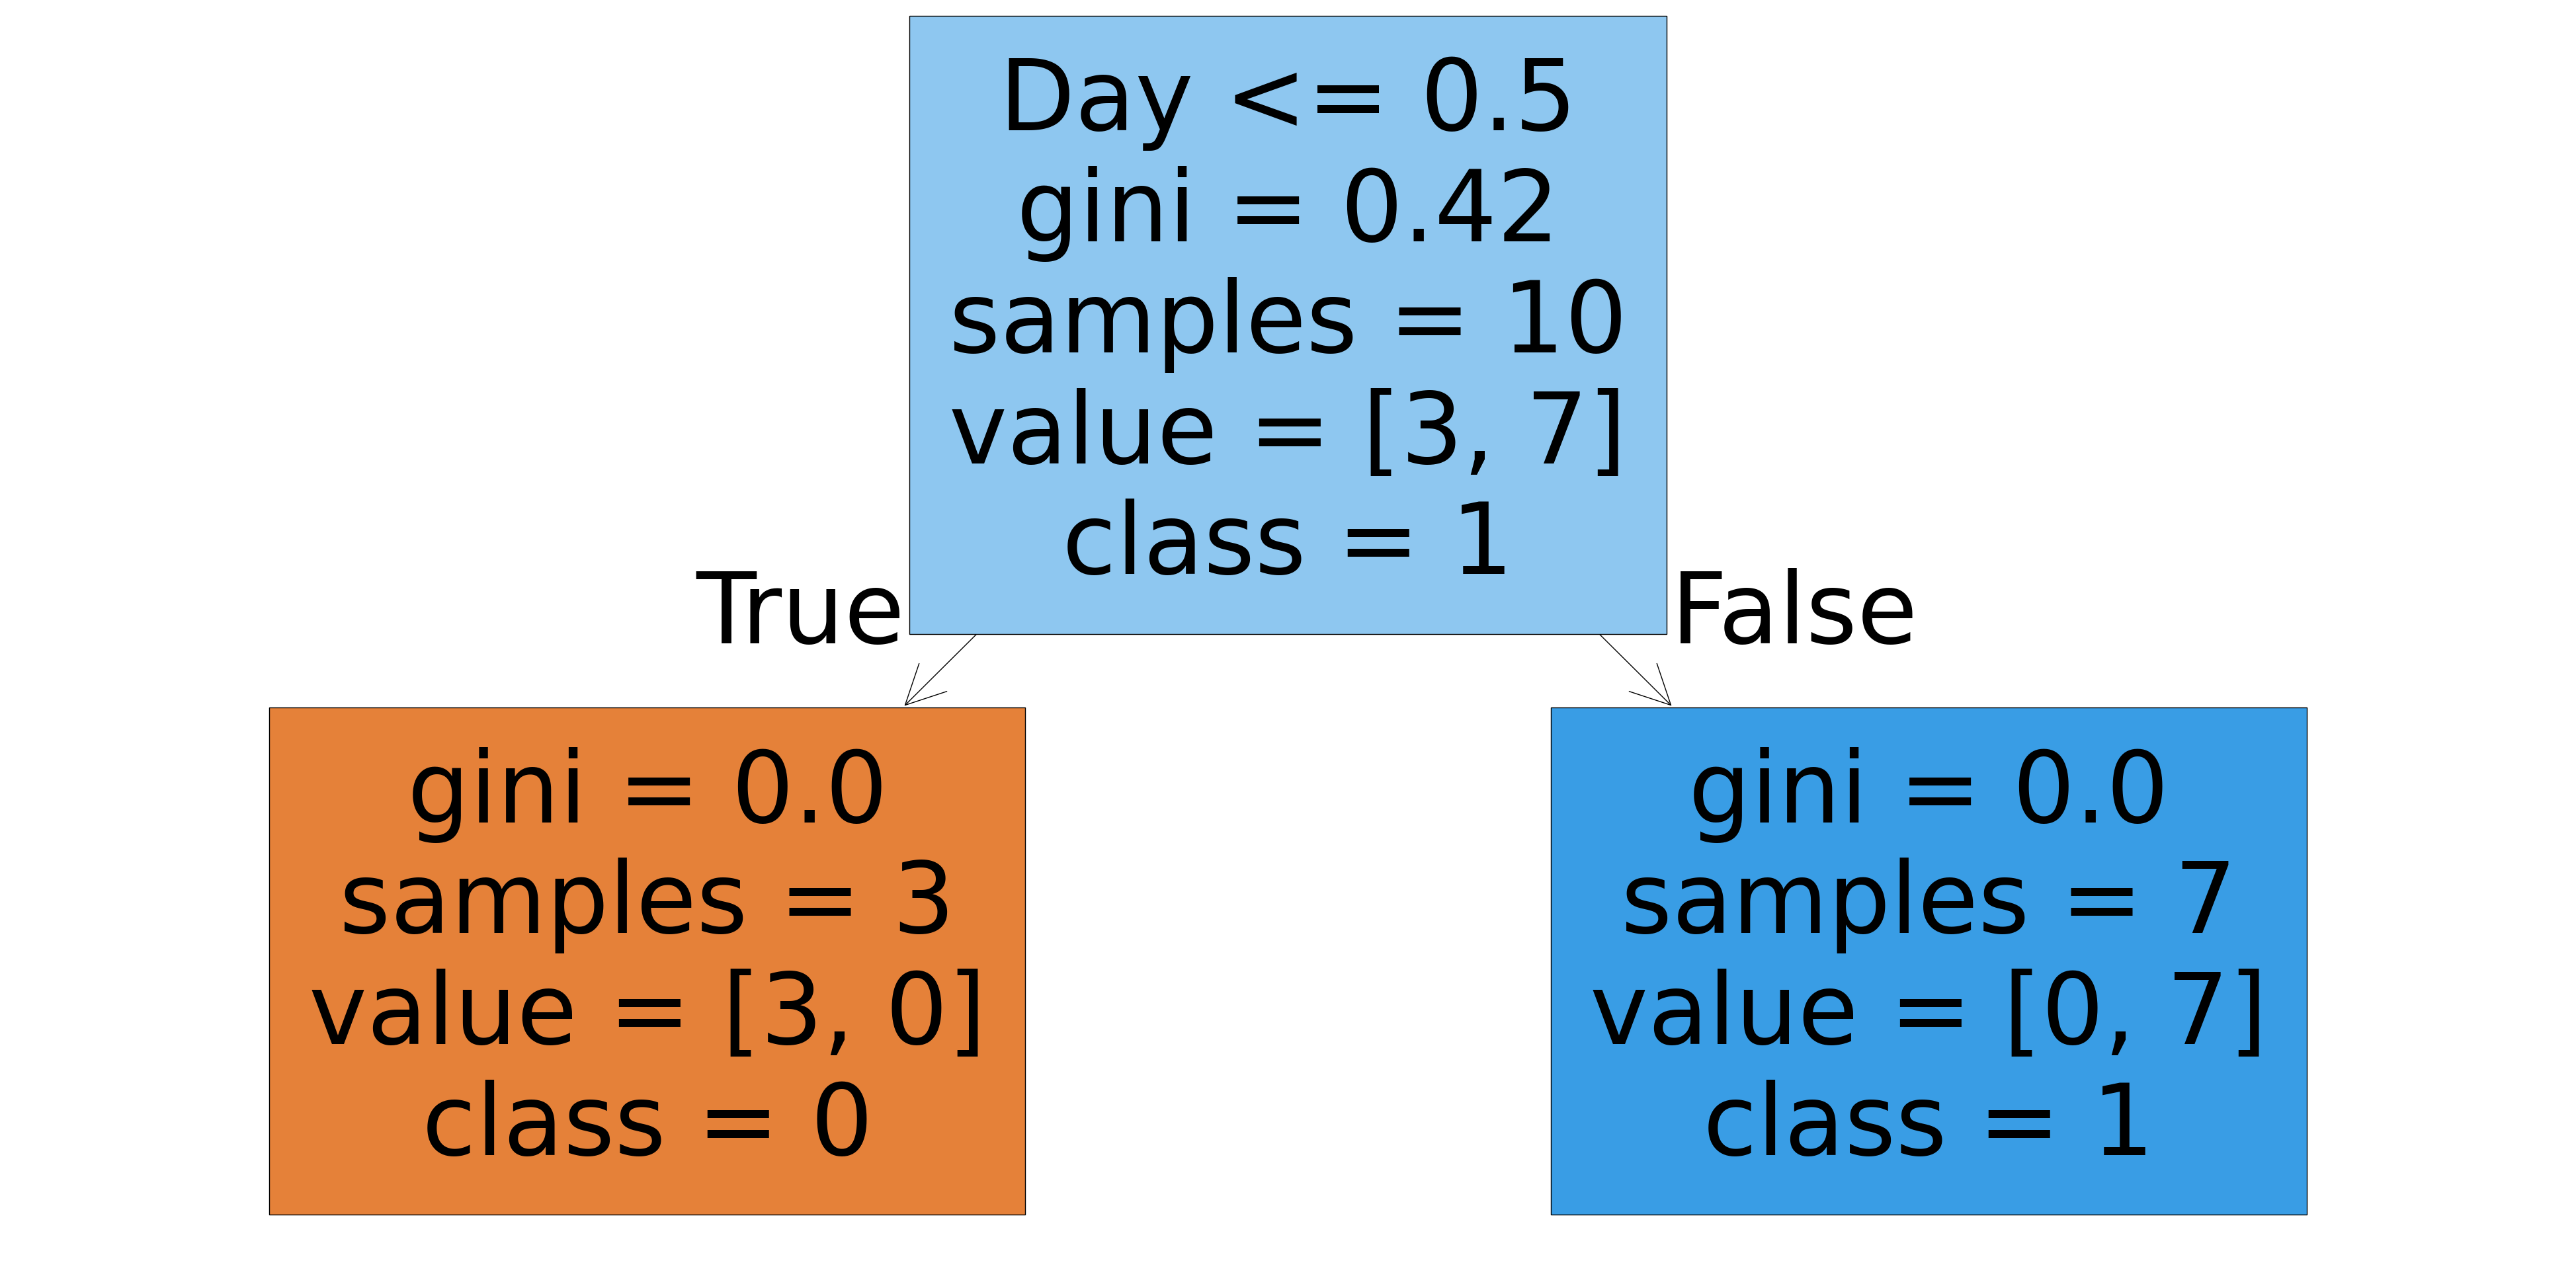

In [ ]:
# prompt: plot the trained

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Assuming dt_classifier2 is your trained DecisionTreeClassifier
plt.figure(figsize=(50,25))
plot_tree(dt1, filled=True, feature_names=X_train.columns, class_names=['0','1'])
plt.show()

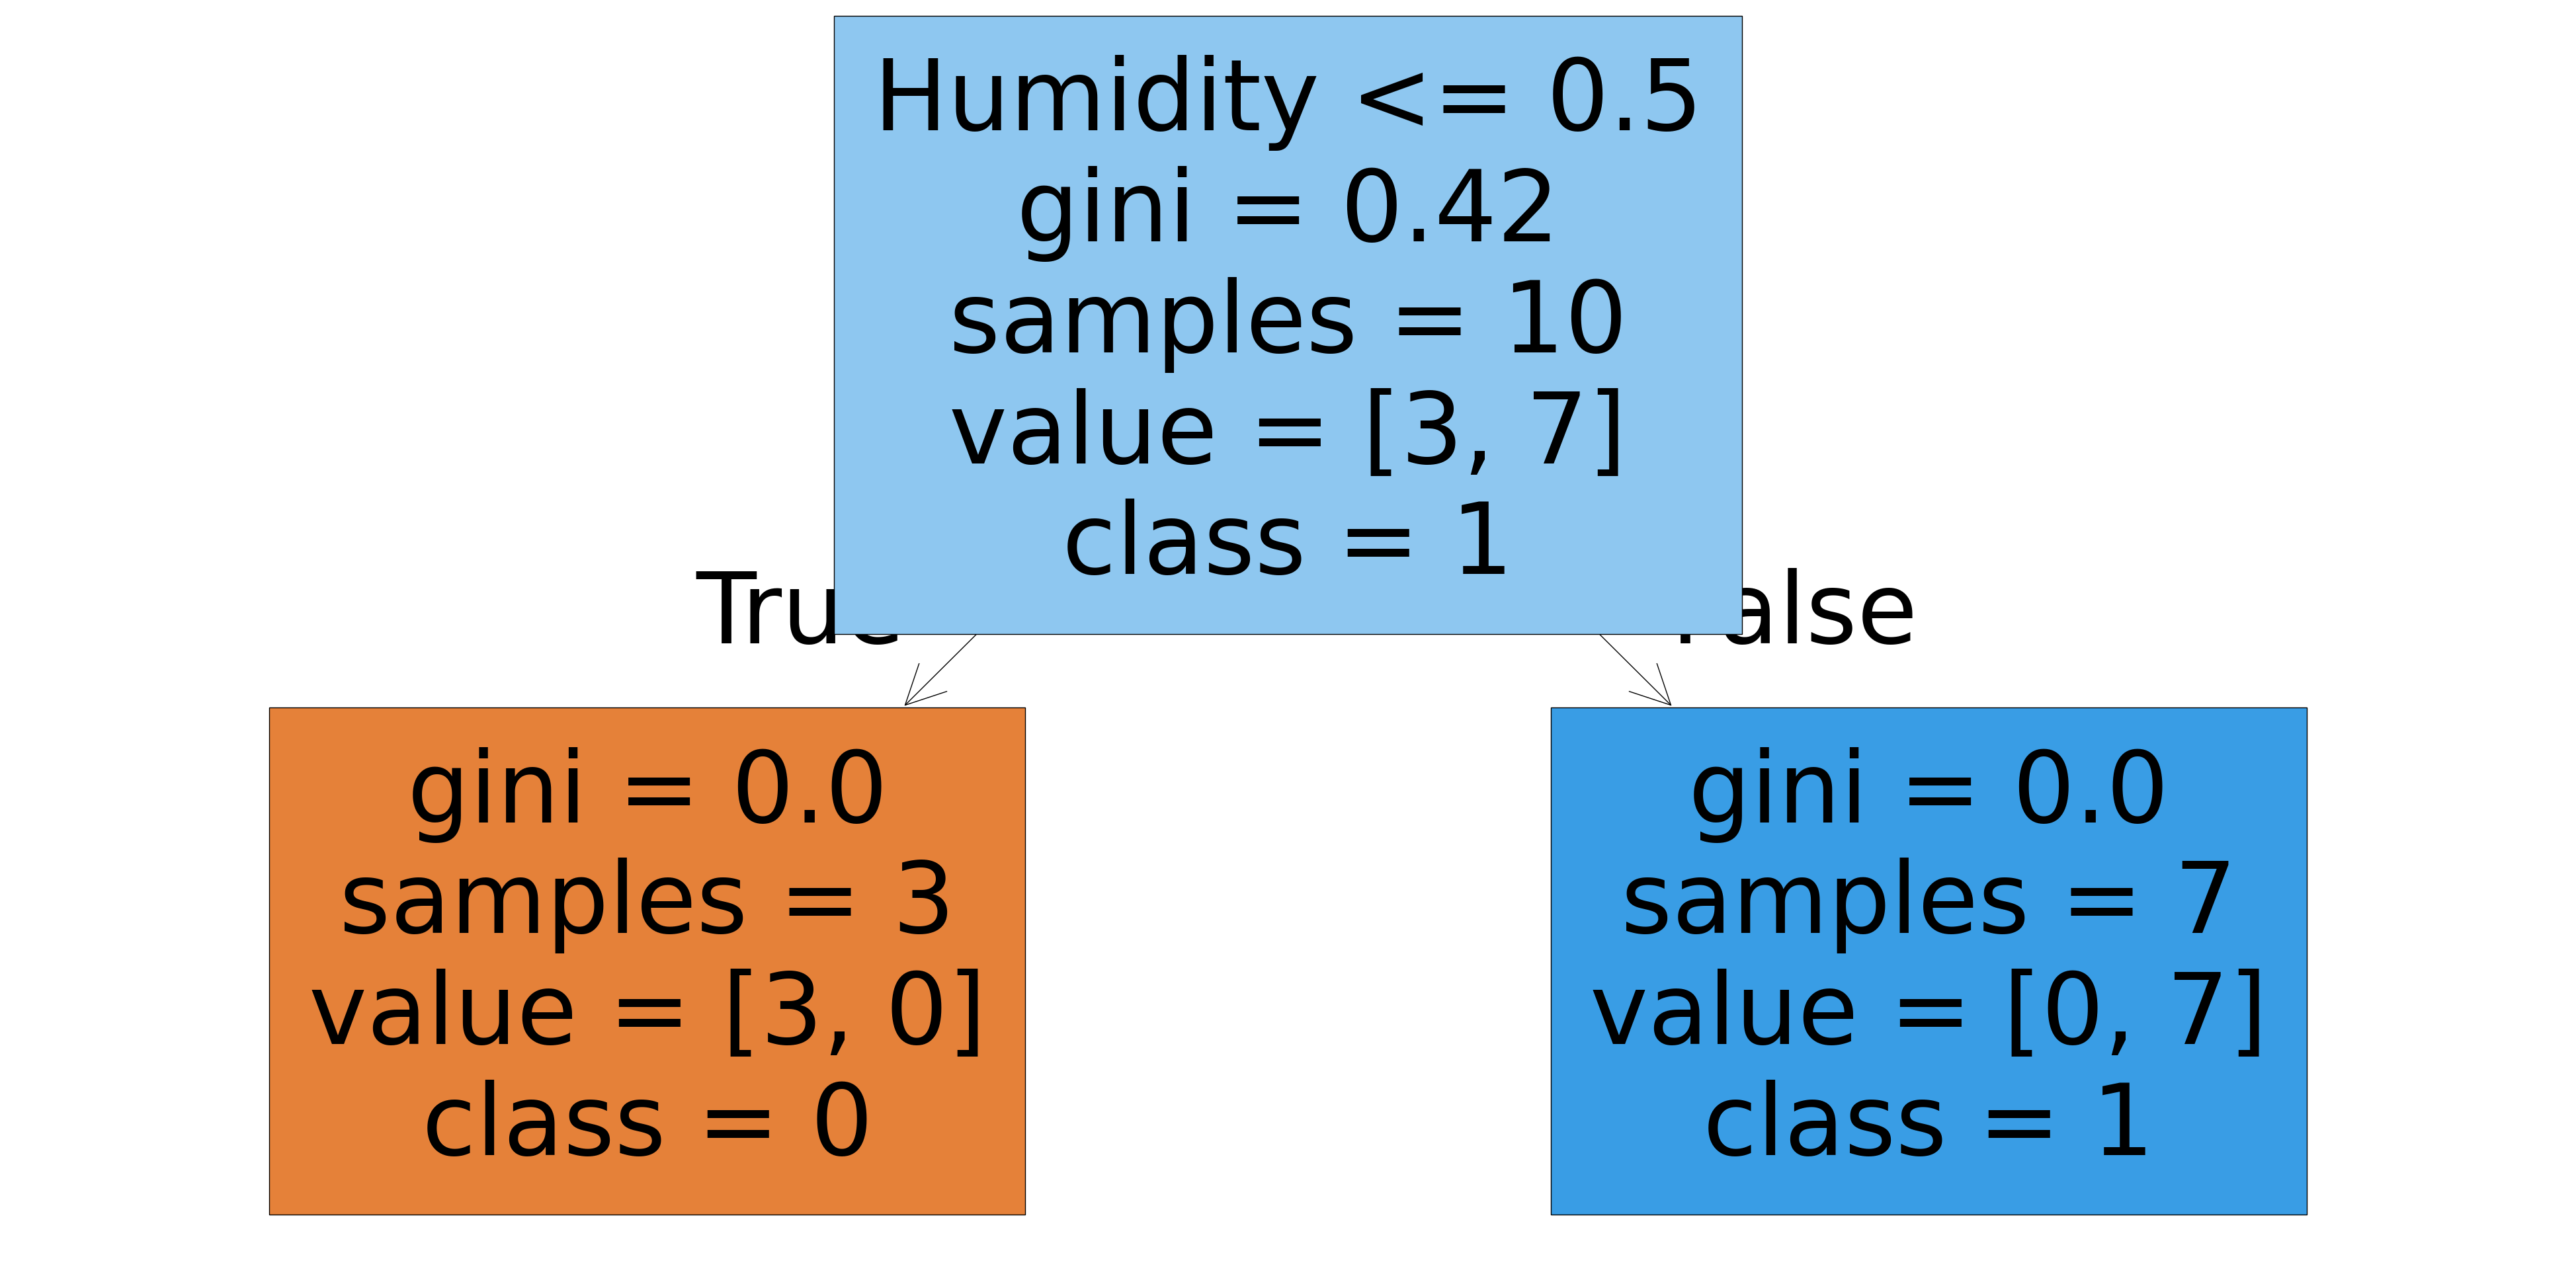

In [ ]:
# prompt: plot the trained

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Assuming dt_classifier2 is your trained DecisionTreeClassifier
plt.figure(figsize=(50,25))
plot_tree(dt2, filled=True, feature_names=X_train.columns, class_names=['0','1'])
plt.show()